#### Loaded only one file ".24" and taken Fs as 20480 (sampling rate). Marked the time "t" cause we will be plotting time series data. Plotted 2000 data from the file.

Total samples: 20480


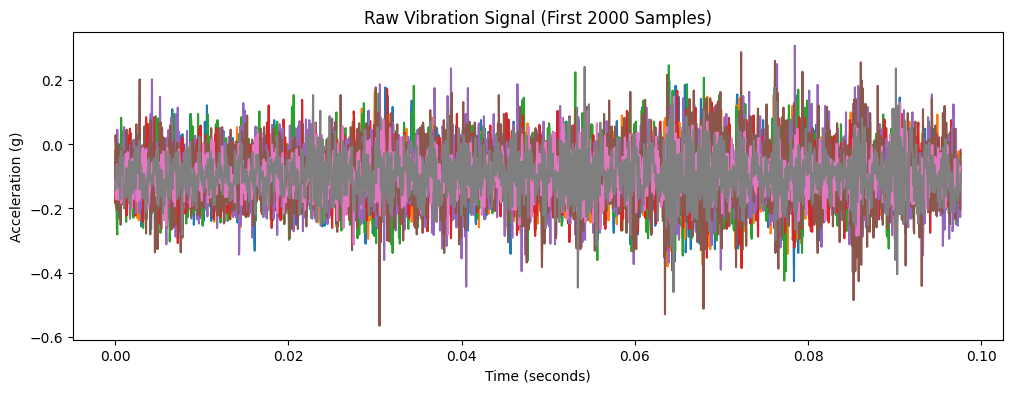

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Updated the path to be relative to the current directory
file_path = "filedata/2003.10.22.12.06.24"

if os.path.exists(file_path):
    # Load raw vibration data
    data = np.loadtxt(file_path)

    Fs = 20480  # Sampling rate (Hz)
    t = np.arange(len(data)) / Fs

    print("Total samples:", len(data))
    plt.figure(figsize=(12,4))
    plt.plot(t[:2000], data[:2000])
    plt.xlabel("Time (seconds)")
    plt.ylabel("Acceleration (g)")
    plt.title("Raw Vibration Signal (First 2000 Samples)")
    plt.show()
else:
    print(f"Error: File not found at {file_path}")
    print("Current working directory:", os.getcwd())
    print("Available files in current directory:", os.listdir('.'))

#### As the data is not centred around zero so we did the DC offset removing to centre it around the 0.

In [ ]:
# Ensure data is loaded from the first file for demonstration
file_path = "filedata/2003.10.22.12.06.24"
data = np.loadtxt(file_path)

data_dc = data - np.mean(data)
print("Mean before:", np.mean(data))
print("Mean after :", np.mean(data_dc))

Mean before: -0.09286718139648438
Mean after : 4.206704429243757e-18


#### Used z score method for basic outlier detection in one file with the kernel size of 5. Then copied the data for the no loss in future to prevent the originality.

In [ ]:
from scipy.signal import medfilt

mean = np.mean(data_dc)
std = np.std(data_dc)

z_scores = (data_dc - mean) / std
outliers = np.abs(z_scores) > 5
cleaned_data = np.copy(data_dc)
cleaned_data[outliers] = mean

# Filtered signal for visualization
filtered = medfilt(cleaned_data[:2000, 2], kernel_size=5)

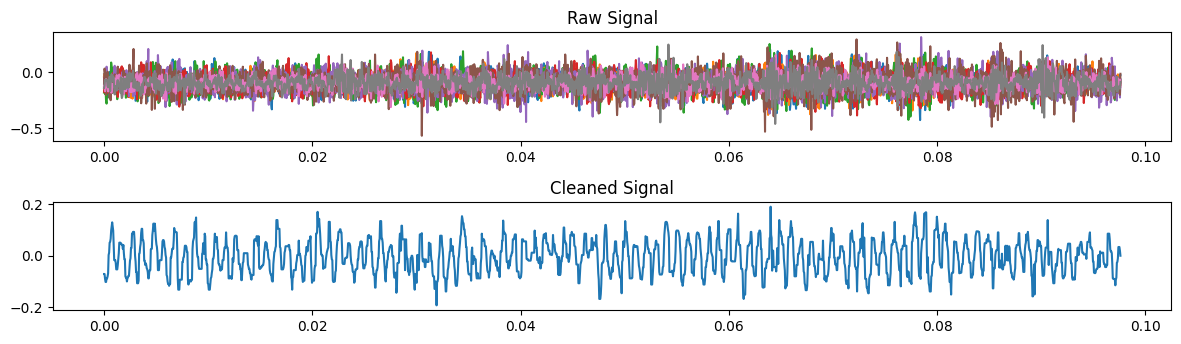

In [ ]:
#Plotted the raw and cleaned data for comparison.
plt.figure(figsize=(12,5))

plt.subplot(3,1,1)
plt.plot(t[:2000], data[:2000])
plt.title("Raw Signal")

plt.subplot(3,1,2)
plt.plot(t[:2000], filtered[:2000])
plt.title("Cleaned Signal")


plt.tight_layout()
plt.show()

### *FFT freq domain data

In [ ]:
print(cleaned_data.shape) # here we are checking how much channel is there for the signal data and it comes out to be 8 so we individually check the data in each channel of the signal in the above code.

(20480, 8)


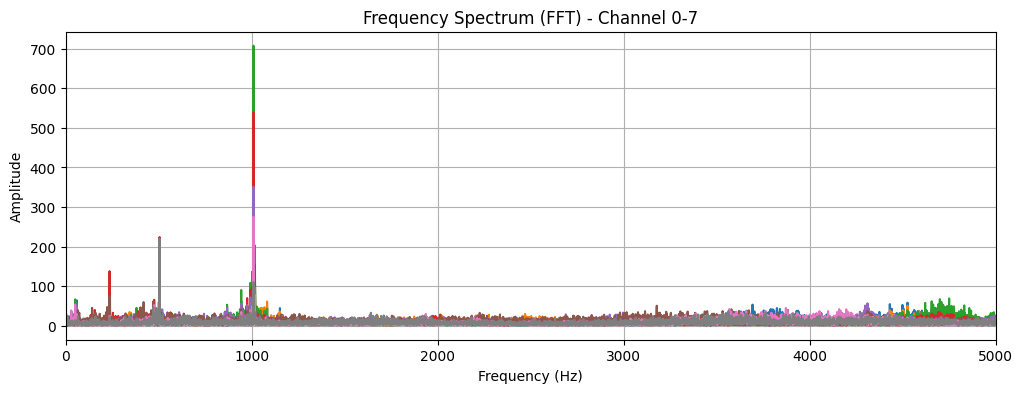

In [ ]:
from scipy.fft import rfft, rfftfreq
signals = cleaned_data[:, :8]
N = len(signals)
Fs = 20480
yf = rfft(signals, axis=0)
xf = rfftfreq(N, 1/Fs)
magnitude = np.abs(yf)

plt.figure(figsize=(12,4))
plt.plot(xf, magnitude[:, :8])
plt.xlim(0, 5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum (FFT) - Channel 0-7")
plt.grid()
plt.show()

### windowing

In [ ]:
signals = cleaned_data[:, :8]
from scipy.signal import windows
# Create the window and reshape it for broadcasting across 8 channels
window = windows.hann(len(signals))[:, np.newaxis]
signal_win = signals * window

from scipy.fft import rfft, rfftfreq
Fs = 20480
N = len(signals)
yf_w = rfft(signal_win, axis=0)
xf_w = rfftfreq(N, 1/Fs)
mag = np.abs(yf_w)

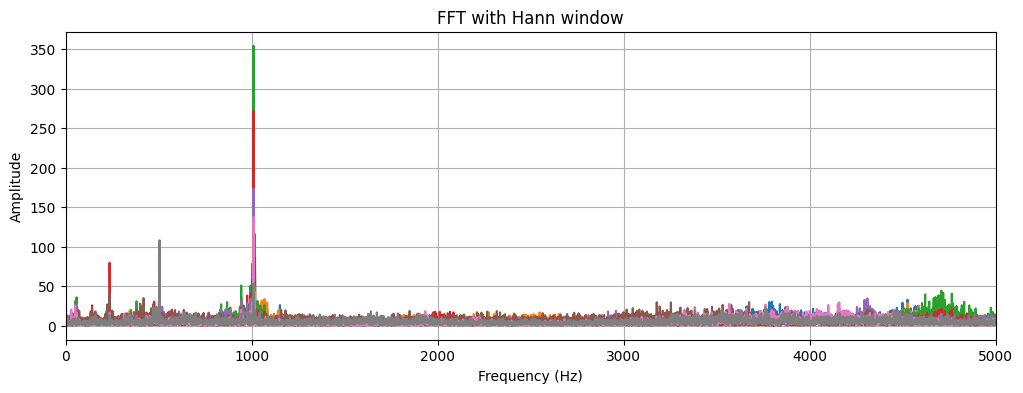

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(xf,mag)
plt.xlim(0,5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT with Hann window")
plt.grid()
plt.show()

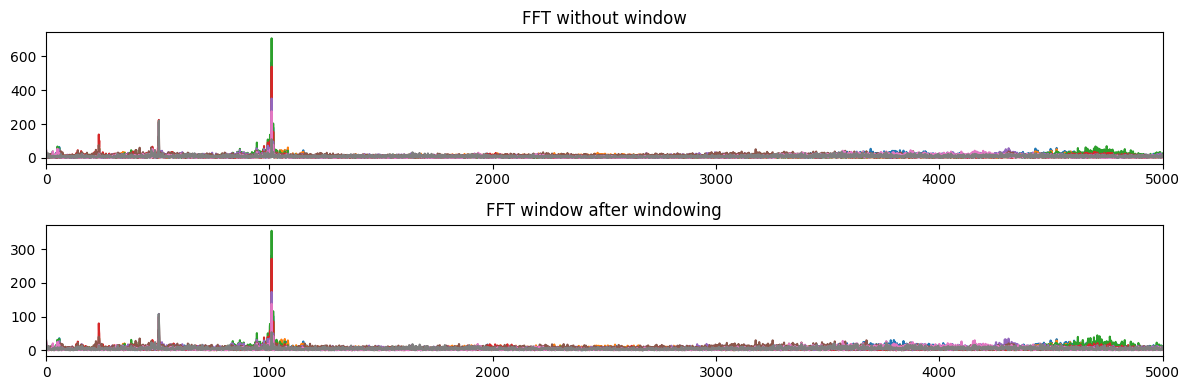

In [ ]:
# Comparing windowed vs non windowed for clarification.
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(xf, magnitude)
plt.title("FFT without window")
plt.xlim(0,5000)

plt.subplot(2,1,2)
plt.plot(xf,mag)
plt.title("FFT window after windowing")
plt.xlim(0,5000)
plt.tight_layout()
plt.show()

### PSD using welch's method after FFT

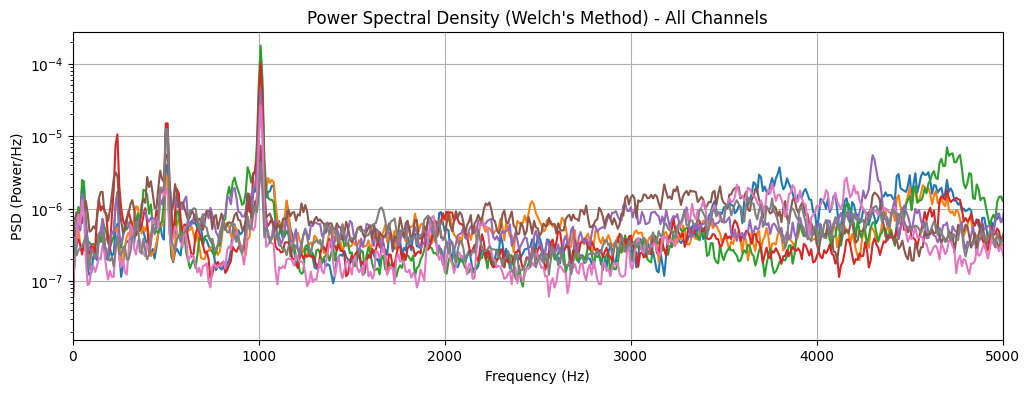

In [ ]:
from scipy.signal import welch

Fs = 20480
signals = cleaned_data[:, :8]

freqs, psd = welch(
    signals,
    fs=Fs,
    window='hann',
    nperseg=2048,
    noverlap=1024,
    scaling='density',
    axis=0
)

plt.figure(figsize=(12,4))
plt.semilogy(freqs, psd)
plt.title("Power Spectral Density (Welch's Method) - All Channels")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (Power/Hz)")
plt.xlim(0, 5000)
plt.grid()
plt.show()

### Plotting of FFT and PSD

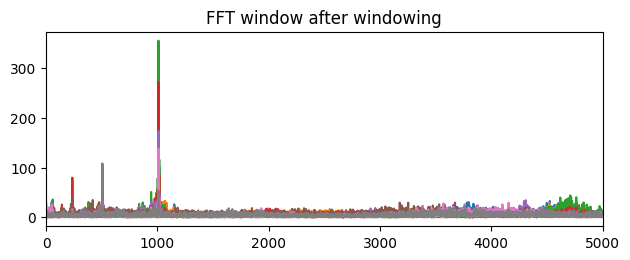

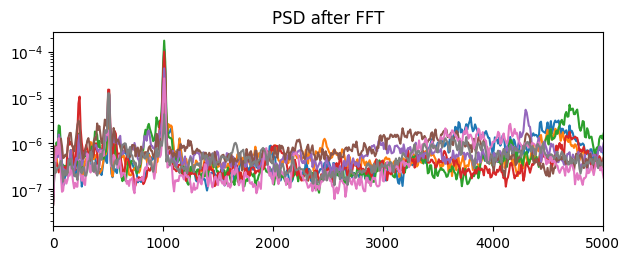

In [ ]:
#Plotting FFT vs PSD
plt.subplot(2,1,1)
plt.plot(xf,mag)
plt.title("FFT window after windowing")
plt.xlim(0,5000)
plt.tight_layout()
plt.show()

plt.subplot(2,1,2)
plt.semilogy(freqs, psd) #plotting using log scale.
plt.title("PSD after FFT")
plt.xlim(0,5000)
plt.tight_layout()
plt.show()


### STFT and Spectrogram

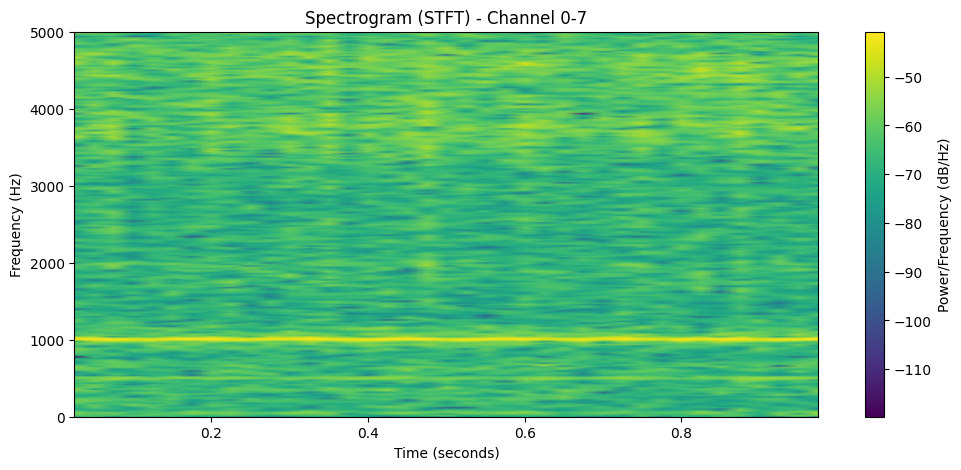

In [ ]:
signals = cleaned_data[:, 0]
Fs = 20480
from scipy.signal import spectrogram

f, t, Sxx = spectrogram( #defining Spectogram function with all the parameters
    signals,
    fs=Fs,
    window='hann',
    nperseg=1024,
    noverlap=512,
    scaling='density',
    axis=0
)
plt.figure(figsize=(12,5))
plt.pcolormesh(t, f, 10*np.log10(Sxx + 1e-12), shading='gouraud') # added small epsilon to avoid log(0)
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (seconds)')
plt.ylim(0, 5000)
plt.title('Spectrogram (STFT) - Channel 0-7')
plt.show()

### Creating feature vector

In [ ]:
signals=cleaned_data[:, :8] #finding rms of the data of the second channel.
rms=np.sqrt(np.mean(signals**2))
print(rms)

0.07963995060730075


In [ ]:
ptp = np.max(signals) - np.min(signals)# finding peak to peak data of the 2nd channel of the signal.
print(ptp)

0.796


In [ ]:
import numpy as np # Calculating the band power and the energy in the particular band width. here we have taken 800-1200hz frequency.

def band_power(freqs, psd, f_low, f_high):
    idx = (freqs >= f_low) & (freqs <= f_high)
    # Use axis=0 if psd is 2D to calculate power for all channels
    return np.trapezoid(psd[idx, :], freqs[idx], axis=0)
bp_1k = band_power(freqs, psd, 800, 1200)
print("Band power (800–1200 Hz) per channel:", bp_1k)

Band power (800–1200 Hz) per channel: [0.00220576 0.0010581  0.00349865 0.0019167  0.00107861 0.00042569
 0.00055964 0.00024372]


### Defined features : rms, std, kurt, bp_1k, centroid, bandwidth, flatness, entropy, crest_factor, shape_factor, impulsive_factor, clearance_factor.

In [ ]:
import numpy as np
from scipy.signal import welch
from scipy.stats import kurtosis

def extract_features(segment, Fs):
    all_features = []

    # Loop over all channels
    for ch in range(segment.shape[1]):
        signals = segment[:, ch]   # 1D signal for this channel

        # -------- Time Domain --------
        rms = np.sqrt(np.mean(signals**2))
        std = np.std(signals)
        kurt = kurtosis(signals, fisher=False)

        # -------- Frequency Domain --------
        freqs, psd = welch(signals, fs=Fs, nperseg=min(len(signals), 2048))

        def band_power(f, p, f_low, f_high):
            idx = (f >= f_low) & (f <= f_high)
            return np.trapezoid(p[idx], f[idx]) if np.any(idx) else 0

        bp_1k = band_power(freqs, psd, 800, 1200)

        centroid = np.sum(freqs * psd) / (np.sum(psd) + 1e-12)
        bandwidth = np.sqrt(np.sum(((freqs - centroid)**2) * psd) / (np.sum(psd) + 1e-12))
        flatness = np.exp(np.mean(np.log(psd + 1e-12))) / (np.mean(psd) + 1e-12)

        psd_norm = psd / (np.sum(psd) + 1e-12)
        entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-12))

        # -------- Shape Features --------
        peak = np.max(np.abs(signals))
        mean_abs = np.mean(np.abs(signals))
        mean_sqrt = np.mean(np.sqrt(np.abs(signals)))

        features = [
            rms, std, kurt, bp_1k,
            centroid, bandwidth, flatness, entropy,
            peak / (rms + 1e-12),
            rms / (mean_abs + 1e-12),
            peak / (mean_abs + 1e-12),
            peak / (mean_sqrt**2 + 1e-12)
        ]

        # Add channel features
        all_features.extend(features)

    return np.array(all_features)

In [ ]:
#Creating segments now:
Fs = 20480
signals = cleaned_data[:, :8]

window_size = Fs // 200
segments = []

for start in range(0, len(signals) - window_size + 1, window_size):
    segment = signals[start:start + window_size, :]
    segments.append(segment)


# Creating dataset for ML as in X
X = []

for segment in segments:
    features = extract_features(segment, Fs)
    X.append(features)

X = np.array(X)

print("Dataset shape:", X.shape) # it checks the shape (1,8) tells us : 1 is the segment with 8 features at once.

Dataset shape: (200, 96)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#### Using Isolation forest as our primary ML model initially.

In [ ]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X_scaled)

IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [ ]:
labels = model.predict(X_scaled)
print(labels) # 1 is normal and -1 is anomaly

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1 -1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1 -1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1 -1  1  1 -1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1]


In [ ]:
import numpy as np

anomaly_indices = np.where(labels == -1)[0]

print("Anomaly segments:", anomaly_indices)

Anomaly segments: [ 42  64  68  95 147 149 166 173 176 179]


In [ ]:
print("Feature matrix:")
print(X)

Feature matrix:
[[0.07078049 0.07013534 2.31942543 ... 1.24128765 3.36723967 4.01747757]
 [0.08551488 0.08549182 2.60781269 ... 1.25929489 4.49085499 5.27959766]
 [0.07680485 0.07660445 2.57170925 ... 1.22650312 2.81172352 3.25793681]
 ...
 [0.07881881 0.07876873 2.25666779 ... 1.2781004  4.41023547 5.25589312]
 [0.07224299 0.07223846 2.61544948 ... 1.25293778 3.01909443 3.58623256]
 [0.08362534 0.08328608 2.78234392 ... 1.24618872 3.20323208 3.7941457 ]]


In [ ]:
print("Segment 9 features:", X[9])# we can check the feature of the anaomaly segment.
print("Segment 8 features:", X[8])

Segment 9 features: [8.38007272e-02 8.32188418e-02 3.01472763e+00 8.27282091e-04
 3.59200195e+03 2.02161017e+03 2.83078020e-01 2.87019664e+00
 2.97291953e+00 1.23262465e+00 3.66449389e+00 4.26301531e+00
 7.55537348e-02 7.52337182e-02 2.53324657e+00 2.43286474e-04
 4.03926086e+03 2.57441900e+03 3.76463735e-01 3.22612983e+00
 2.45034636e+00 1.20568301e+00 2.95434097e+00 3.36477253e+00
 9.08222079e-02 9.08147712e-02 3.20136734e+00 2.23225890e-03
 2.44774183e+03 2.24421937e+03 3.46334462e-01 2.91924995e+00
 2.98531411e+00 1.26836292e+00 3.78646173e+00 4.53114464e+00
 8.57084492e-02 8.56954161e-02 2.61514939e+00 5.67051449e-04
 3.36335572e+03 3.13933459e+03 3.80377828e-01 3.13269526e+00
 2.25336965e+00 1.22978078e+00 2.77115069e+00 3.21061589e+00
 9.65781409e-02 9.65466726e-02 3.57144512e+00 4.58695968e-04
 4.92170755e+03 2.93524969e+03 5.01339325e-01 3.57768267e+00
 3.13873114e+00 1.25651135e+00 3.94385130e+00 4.57258593e+00
 1.01609382e-01 1.00927662e-01 2.83540867e+00 1.84438546e-04
 4.8

### Plotted anomalies in one file using ISO.

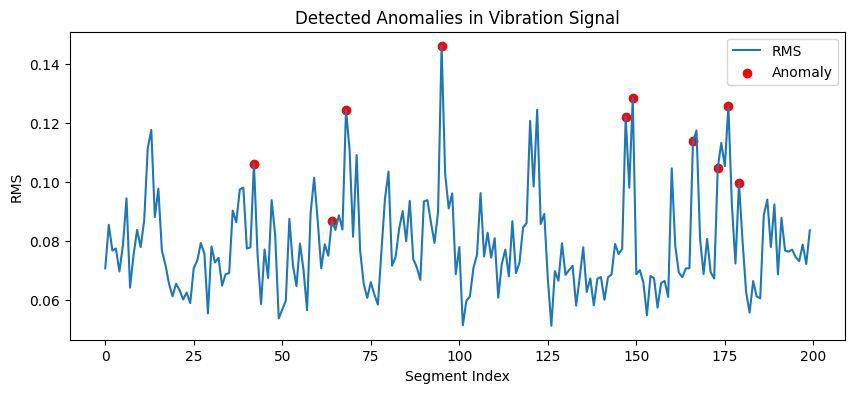

In [ ]:
import matplotlib.pyplot as plt

rms_values = X[:,0]

plt.figure(figsize=(10,4))
plt.plot(rms_values, label="RMS")

plt.scatter(anomaly_indices,
            rms_values[anomaly_indices],
            color='red',
            label='Anomaly')

plt.xlabel("Segment Index")
plt.ylabel("RMS")
plt.title("Detected Anomalies in Vibration Signal")
plt.legend()
plt.show()

#### Did Hilbert Transformation for envelope analysis.


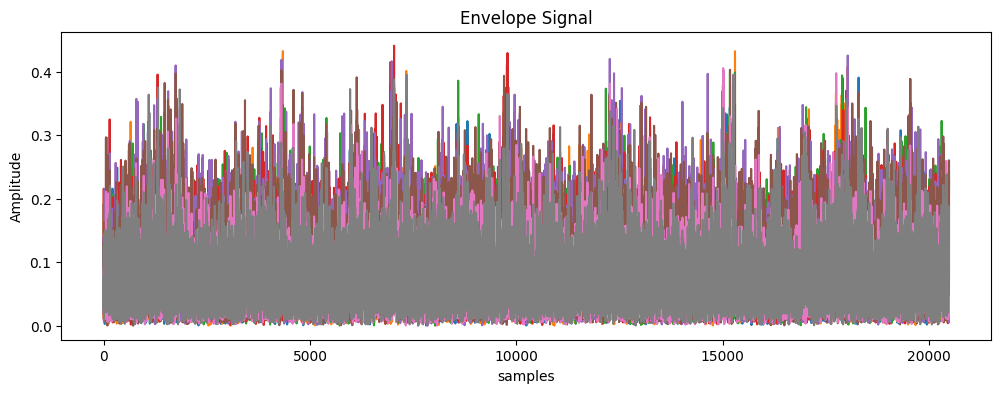

In [ ]:
# Did envelope analysis cause FFT alone is not enough.
from scipy.signal import hilbert
signal=signals
analytic_signal=hilbert(signal)
envelope=np.abs(analytic_signal)
plt.figure(figsize=(12,4))
plt.plot(envelope)
plt.title("Envelope Signal")
plt.xlabel("samples")
plt.ylabel("Amplitude")
plt.show()

#### Plotted envelope spectrum

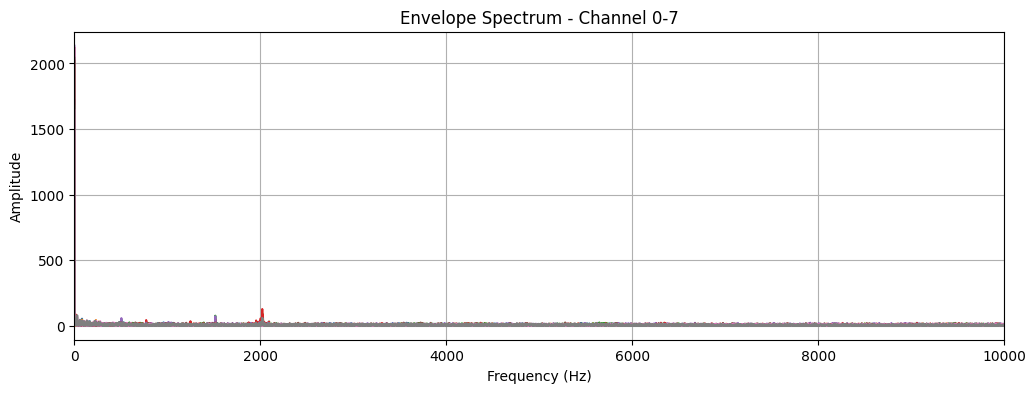

In [ ]:
yf_env = np.abs(np.fft.rfft(envelope, axis=0))

xf_env = np.fft.rfftfreq(len(envelope), 1/Fs)

plt.figure(figsize=(12,4))

# Plotting the envelope spectrum (Channel 0 as an example)
plt.plot(xf_env, yf_env[:, :8])

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Envelope Spectrum - Channel 0-7")

plt.xlim(0, 10000)
plt.grid()
plt.show()

The result till now is "no fault" getting. If there have been a fault in the spectrum then the peaks would have been periodic and the frequency would be increasing constantly.

In [ ]:
mask = (xf_env >= 500) & (xf_env <= 510)
xf_filtered = xf_env[mask]
yf_filtered = yf_env[mask]
print(yf_filtered)

[[ 6.99422598  6.91484284 14.54170278 14.79724825 15.26409227 20.54803838
  15.93328661  8.09900171]
 [21.5208551  11.78931748  9.77894828 15.98974472 18.77337315 17.61364924
   9.94380455 14.45873111]
 [ 2.6256924   8.22811142 12.65063791  1.22438477 17.32811355 15.84558706
   6.07171355  0.7580788 ]
 [ 6.07785193  4.54656574  5.71695172  8.5553535   9.08878375  6.75611104
   8.16906039 10.1236509 ]
 [ 9.33970096 11.62310531  9.71303901  2.5557519   0.99340573 13.37006653
   8.36885536 11.67509464]
 [15.99008128 35.45731813 47.00221292 30.41769661 57.84499869 25.01848102
  20.31286083 19.67575905]
 [ 4.10961781  6.20846552  7.45315177  9.44672099  7.97254129 14.70897177
   4.88539444  1.48875051]
 [ 4.03145287  6.02851772  2.01912846  7.77100313 11.78661603 11.04220161
   6.52984868  1.66920472]
 [ 8.86098531 11.4537615   6.67815349  8.32690007  8.34981063 19.76754838
  12.86757858  6.15885805]
 [18.89726738 26.89378476  6.27759498 16.38257353 19.76273935 15.94535419
  16.87027211 19.

form the bove code i tried printing the y coordinate for the spikes from the spectrum of envelop. but turns out nothing is much wrong here, everythig is just normal.  

### Using OneClassSVM

In [ ]:
# Moved to our next model for cross verification of the anamolies.
from sklearn.svm import OneClassSVM
svm_model=OneClassSVM(
    kernel='rbf',
    nu=0.05,
    gamma='scale'
)
svm_labels=svm_model.fit_predict(X_scaled)
print(svm_labels)

[-1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1
  1  1  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1  1
 -1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1 -1  1  1  1
 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1 -1 -1  1  1  1  1 -1  1 -1
  1  1 -1  1  1 -1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1 -1 -1  1
  1  1  1  1  1 -1  1 -1 -1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1]


### Using Autoencoders

In [ ]:
# One of the best models for anomalies detection as per the previous research.
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_scaled, X_scaled,
                epochs=50,
                batch_size=16,
                verbose=0)

In [ ]:
# did reconstruction as a part of our AE.
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean((X_scaled - reconstructions)**2, axis=1)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [ ]:
threshold = np.percentile(mse, 95)

ae_labels = np.where(mse > threshold, -1, 1)
print(ae_labels) # printing anomalies found by AE.

[-1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1]


### Comparing results

In [ ]:
print("Isolation Forest anomalies:", np.sum(labels == -1))
print("One-Class SVM anomalies:", np.sum(svm_labels == -1))
print("Autoencoder anomalies:", np.sum(ae_labels == -1))

Isolation Forest anomalies: 10
One-Class SVM anomalies: 27
Autoencoder anomalies: 10


### plotting of three models

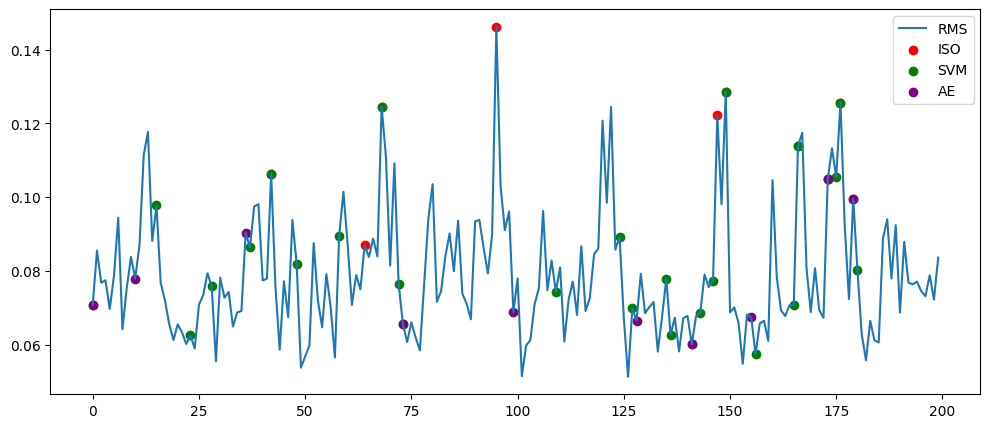

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(X[:,0], label="RMS")

plt.scatter(np.where(labels==-1),
            X[labels==-1,0],
            color='red', label='ISO')

plt.scatter(np.where(svm_labels==-1),
            X[svm_labels==-1,0],
            color='green', label='SVM')

plt.scatter(np.where(ae_labels==-1),
            X[ae_labels==-1,0],
            color='purple', label='AE')

plt.legend()
plt.show()

In [ ]:
combined = (labels == -1).astype(int) + \
           (svm_labels == -1).astype(int) + \
           (ae_labels == -1).astype(int)

# High confidence anomalies
strong_anomalies = np.where(combined >= 2)[0]
print(strong_anomalies)

[  0  42  68  73 141 149 166 173 176 179]


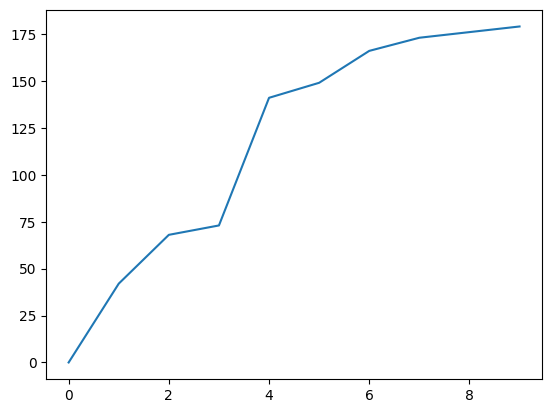

In [ ]:
plt.plot(strong_anomalies)

### Counting anomaly over time for each second

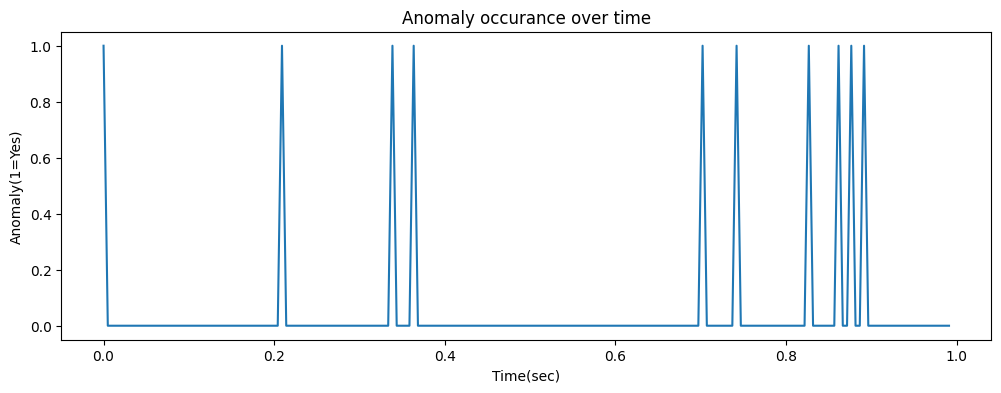

In [ ]:
time=np.arange(len(X))*(window_size/Fs)
anomaly_signal=(combined>=2).astype(int)
plt.figure(figsize=(12,4))
plt.plot(time,anomaly_signal)
plt.xlabel("Time(sec)")
plt.ylabel("Anomaly(1=Yes)")
plt.title("Anomaly occurance over time")
plt.show()

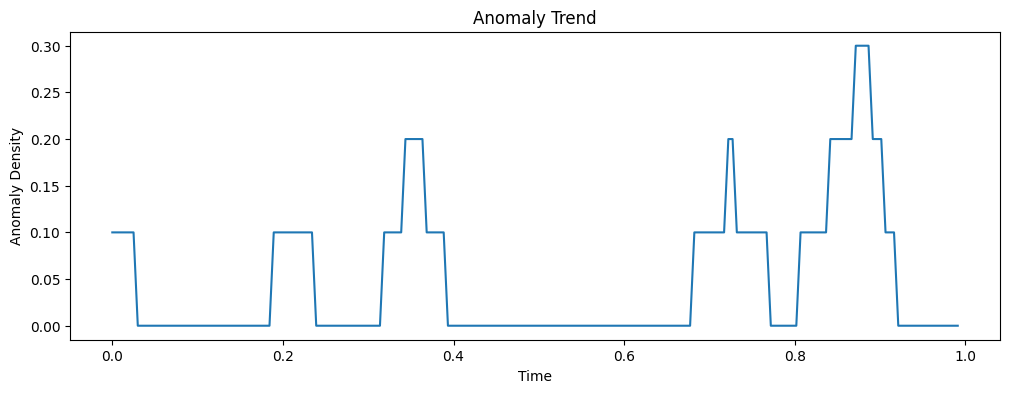

In [ ]:
window = 10
trend = np.convolve(anomaly_signal, np.ones(window)/window, mode='same')

plt.figure(figsize=(12,4))
plt.plot(time, trend)
plt.title("Anomaly Trend")
plt.xlabel("Time")
plt.ylabel("Anomaly Density")
plt.show()

Text(0.5, 1.0, 'rms over time')

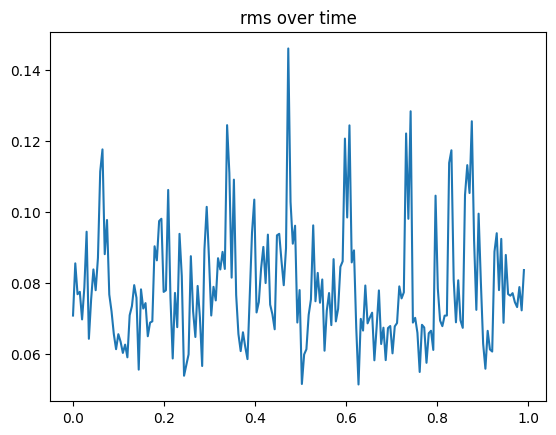

In [ ]:
# plotting feature values individually.
plt.plot(time, X[:,0]) #in feature vector the index 0 is rms
plt.title("rms over time")

### Now we will check for multiple files and do some more work

In [ ]:
def extract_features(signal, Fs):
    # This function now expects a single 1D signal as input

    # ---- Time Domain ----
    rms = np.sqrt(np.mean(signal**2))
    std = np.std(signal)
    kurt = kurtosis(signal, fisher=False)

    # ---- Frequency Domain ----
    # Ensure psd calculation handles potential empty arrays or all-zero signals gracefully
    freqs, psd = welch(signal, fs=Fs, nperseg=min(len(signal), 256)) # Added nperseg for robustness

    # Add a small epsilon to psd to prevent division by zero or log of zero
    psd_epsilon = psd + 1e-12
    sum_psd = np.sum(psd_epsilon)

    centroid = np.sum(freqs * psd_epsilon) / sum_psd
    bandwidth = np.sqrt(np.sum(((freqs - centroid)**2) * psd_epsilon) / sum_psd)
    flatness = np.exp(np.mean(np.log(psd_epsilon))) / np.mean(psd_epsilon)

    psd_norm = psd_epsilon / sum_psd
    entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-12))

    # ---- Shape Features ----
    peak = np.max(np.abs(signal))
    mean_abs = np.mean(np.abs(signal))
    mean_sqrt = np.mean(np.sqrt(np.abs(signal)))

    # Add a small epsilon to denominators to prevent division by zero
    crest = peak / (rms + 1e-12)
    shape = rms / (mean_abs + 1e-12)
    impulse = peak / (mean_abs + 1e-12)
    clearance = peak / (mean_sqrt**2 + 1e-12)

    features = [
        rms, std, kurt,
        centroid, bandwidth, flatness, entropy,
        crest, shape, impulse, clearance
    ]

    return np.array(features)

### Here we have defined segments again for the next all file work.

In [ ]:
def create_segments(signals, Fs):
    window_size = Fs
    segments = []

    for start in range(0, len(signals) - window_size + 1, window_size):
        segments.append(signals[start:start + window_size])

    return segments

### Loading AE

In [ ]:
def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(8, activation='relu')(input_layer)
    decoded = Dense(input_dim, activation='linear')(encoded)

    model = Model(inputs=input_layer, outputs=decoded)
    model.compile(optimizer='adam', loss='mse')

    return model

### Main pipeline with combination of all the features data from all the 8 channels.

In [ ]:
import os
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

folder_path = 'filedata' # Define folder_path
files = sorted(os.listdir(folder_path))
print("Files found:", files)

anomaly_counts = []
anomaly_scores = []
all_anomaly_indices = []

for file in files:

    print(f"\nProcessing: {file}")

    # -------- LOAD FILE --------
    file_path = os.path.join(folder_path, file)
    data = np.loadtxt(file_path)
    signals = data[:, :8]

    # -------- SEGMENTATION --------
    segments = []
    for start in range(0, len(signals) - window_size + 1, window_size):
        segment = signals[start:start + window_size, :]
        segments.append(segment)

    # -------- FEATURE EXTRACTION --------
    # -------- FEATURE EXTRACTION (MULTI-CHANNEL FUSION) --------
    X = []

    for segment in segments:
        feature_vector = []

        for ch in range(segment.shape[1]):   # loop over 8 channels
            f = extract_features(segment[:, ch], Fs)  # pass 1D signal
            feature_vector.extend(f)

        X.append(feature_vector)

    X = np.array(X)

    print("Feature variance:", np.var(X))  # debug

    # -------- SCALING --------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # -------- MODELS --------
    iso = IsolationForest(contamination=0.1, random_state=42)
    iso_labels = iso.fit_predict(X_scaled)

    svm = OneClassSVM(nu=0.1)
    svm_labels = svm.fit_predict(X_scaled)

    # -------- AUTOENCODER --------
    ae = build_autoencoder(X_scaled.shape[1])
    ae.fit(X_scaled, X_scaled,
                epochs=10,
                batch_size=16,
                verbose=0)

    recon = ae.predict(X_scaled)
    mse = np.mean((X_scaled - recon)**2, axis=1)

    threshold_ae = np.percentile(mse, 95)
    ae_labels = np.where(mse > threshold_ae, -1, 1)

    # -------- ENSEMBLE --------
    iso_bin = (iso_labels == -1).astype(int)
    svm_bin = (svm_labels == -1).astype(int)
    ae_bin  = (ae_labels == -1).astype(int)

    print("ISO:", np.sum(iso_bin),
          "SVM:", np.sum(svm_bin),
          "AE:", np.sum(ae_bin))

    # -------- ADAPTIVE WEIGHTS --------
    iso_conf = np.mean(iso_bin)
    svm_conf = np.mean(svm_bin)
    ae_conf  = np.mean(ae_bin)

    total_conf = iso_conf + svm_conf + ae_conf + 1e-6

    w_iso = iso_conf / total_conf
    w_svm = svm_conf / total_conf
    w_ae  = ae_conf  / total_conf

    # -------- WEIGHTED SCORE --------
    weighted_score = (
        w_iso * iso_bin +
        w_svm * svm_bin +
        w_ae  * ae_bin
    )

    final_anomalies = (weighted_score >= 0.5).astype(int)

    # -------- RESULTS --------
    anomaly_indices = np.where(final_anomalies == 1)[0]
    anomaly_count = np.sum(final_anomalies)
    anomaly_score = np.sum(weighted_score)

    print(f"Count: {anomaly_count}")
    print(f"Score: {anomaly_score:.2f}")
    print(f"Indices: {anomaly_indices}")

    anomaly_counts.append(anomaly_count)
    anomaly_scores.append(anomaly_score)
    all_anomaly_indices.append(anomaly_indices)

Files found: ['2003.10.22.12.06.24', '2003.10.22.12.09.13', '2003.10.22.12.14.13', '2003.10.22.12.19.13', '2003.10.22.12.24.13', '2003.10.22.12.29.13', '2003.10.22.12.34.13', '2003.10.22.12.39.13', '2003.10.22.12.44.13', '2003.10.22.12.49.13', '2003.10.22.12.54.13', '2003.10.22.12.59.13', '2003.10.22.13.04.13', '2003.10.22.13.09.13', '2003.10.22.13.14.13', '2003.10.22.13.19.13', '2003.10.22.13.24.13', '2003.10.22.13.29.13', '2003.10.22.13.34.13', '2003.10.22.13.39.13', '2003.10.22.13.44.13', '2003.10.22.13.49.13', '2003.10.22.13.54.13', '2003.10.22.13.59.13', '2003.10.22.14.04.13', '2003.10.22.14.09.13', '2003.10.22.14.14.13', '2003.10.22.14.19.13', '2003.10.22.14.24.13', '2003.10.22.14.29.13', '2003.10.22.14.34.13', '2003.10.22.14.39.13', '2003.10.22.14.44.13', '2003.10.22.14.49.13', '2003.10.22.14.54.13', '2003.10.22.14.59.13', '2003.10.22.15.04.13', '2003.10.22.15.09.13']

Processing: 2003.10.22.12.06.24
Feature variance: 1714932.922948976
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
ISO: 

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
ISO: 20 SVM: 36 AE: 10
Count: 36
Score: 27.21
Indices: [  0   1   9  29  31  47  48  51  55  60  71  74  75  78  85  88  95 104
 106 109 120 123 125 131 132 137 143 157 158 159 160 175 182 184 185 191]

Processing: 2003.10.22.12.14.13
Feature variance: 1700458.286174905


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
ISO: 20 SVM: 30 AE: 10
Count: 12
Score: 23.33
Indices: [ 13  55  61  65  94  97 109 122 146 148 175 190]

Processing: 2003.10.22.12.19.13
Feature variance: 1717097.3553412817
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
ISO: 20 SVM: 24 AE: 10
Count: 12
Score: 19.93
Indices: [  5  34  51  64  88  91 141 155 157 169 195 199]

Processing: 2003.10.22.12.24.13
Feature variance: 1709140.0780514493
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
ISO: 20 SVM: 32 AE: 10
Count: 32
Score: 24.58
Indices: [  6   7   8  10  11  28  37  47  53  61  63  69  88  90  91  95  97 108
 109 117 128 140 143 144 145 147 150 157 161 163 171 188]

Processing: 2003.10.22.12.29.13
Feature variance: 1742688.1549613462
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
ISO: 20 SVM: 30 AE: 10
Count: 8
Score: 23.33
Indices: [ 20  74  77 101 126 128 130 180]

Processing: 2003.10.22.12.34.13
Feature variance: 1697939.9643313887
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
ISO: 20 SVM: 33 AE: 10
Count: 33
Score: 25.22


### Plotting graph for multiple file index with anomaly score.

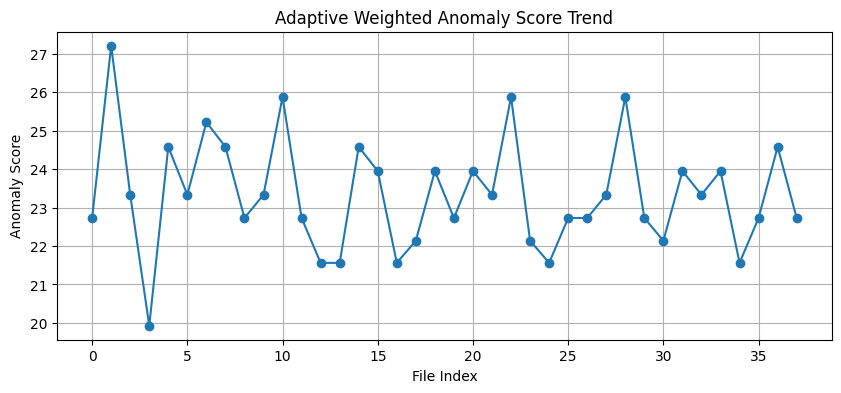

In [ ]:
# Anomaly score tells us how abnormal the data is?
plt.figure(figsize=(10,4))
plt.plot(anomaly_scores, marker='o')

plt.title("Adaptive Weighted Anomaly Score Trend")
plt.xlabel("File Index")
plt.ylabel("Anomaly Score")

plt.grid()
plt.show()

### Anomaly score with trend

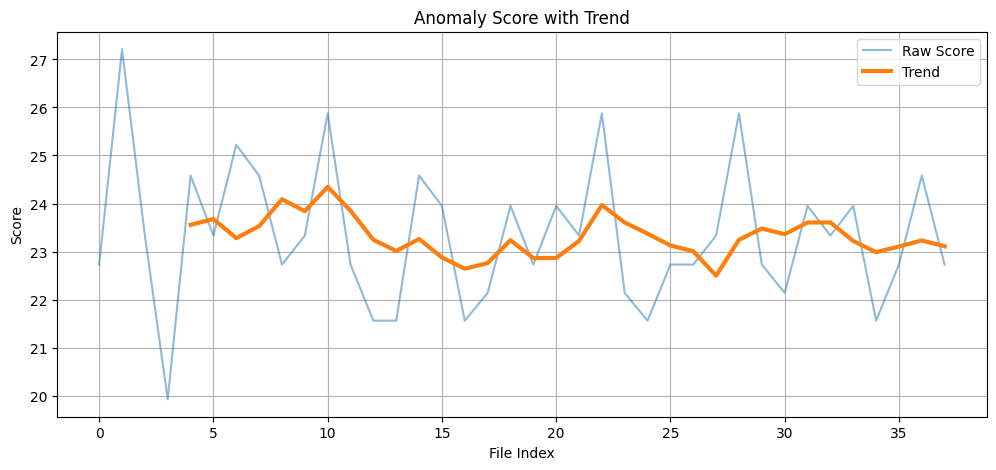

In [ ]:
import numpy as np

window = 5
smooth = np.convolve(anomaly_scores, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12,5))
plt.plot(anomaly_scores, label="Raw Score", alpha=0.5)
plt.plot(range(window-1, len(anomaly_scores)), smooth, linewidth=3, label="Trend")

plt.legend()
plt.title("Anomaly Score with Trend")
plt.xlabel("File Index")
plt.ylabel("Score")
plt.grid()
plt.show()

In [ ]:
print(f"Weights → ISO: {w_iso:.2f}, SVM: {w_svm:.2f}, AE: {w_ae:.2f}")

Weights → ISO: 0.34, SVM: 0.49, AE: 0.17


### Anomaly count

In [ ]:
for i in range(len(anomaly_counts)):
    print(f"\nFile {i}:")
    print(f"Count: {anomaly_counts[i]}")
    print(f"Score: {anomaly_scores[i]:.2f}")
    print(f"Indices: {all_anomaly_indices[i]}")


File 0:
Count: 14
Score: 22.73
Indices: [ 12  68  69  95 120 147 149 153 160 166 173 175 176 179]

File 1:
Count: 36
Score: 27.21
Indices: [  0   1   9  29  31  47  48  51  55  60  71  74  75  78  85  88  95 104
 106 109 120 123 125 131 132 137 143 157 158 159 160 175 182 184 185 191]

File 2:
Count: 12
Score: 23.33
Indices: [ 13  55  61  65  94  97 109 122 146 148 175 190]

File 3:
Count: 12
Score: 19.93
Indices: [  5  34  51  64  88  91 141 155 157 169 195 199]

File 4:
Count: 32
Score: 24.58
Indices: [  6   7   8  10  11  28  37  47  53  61  63  69  88  90  91  95  97 108
 109 117 128 140 143 144 145 147 150 157 161 163 171 188]

File 5:
Count: 8
Score: 23.33
Indices: [ 20  74  77 101 126 128 130 180]

File 6:
Count: 33
Score: 25.22
Indices: [  4  12  19  24  26  29  30  32  37  39  46  47  71  72  74  79  84  90
 102 105 115 119 137 140 142 143 163 164 176 185 190 192 199]

File 7:
Count: 32
Score: 24.58
Indices: [  8  14  17  18  27  31  37  53  63  64  65  70  71  72  76  83  92

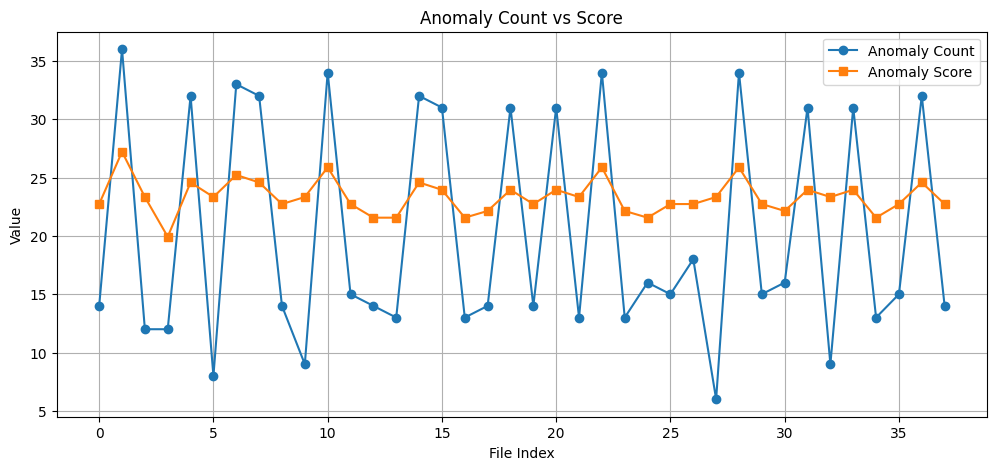

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(anomaly_counts, label="Anomaly Count", marker='o')
plt.plot(anomaly_scores, label="Anomaly Score", marker='s')

plt.title("Anomaly Count vs Score")
plt.xlabel("File Index")
plt.ylabel("Value")

plt.legend()
plt.grid()

plt.show()

### The next, are the experiments we are going to perform for the validation and proof of our novelty.

## Experiment 1. (Single model VS Ensembled)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


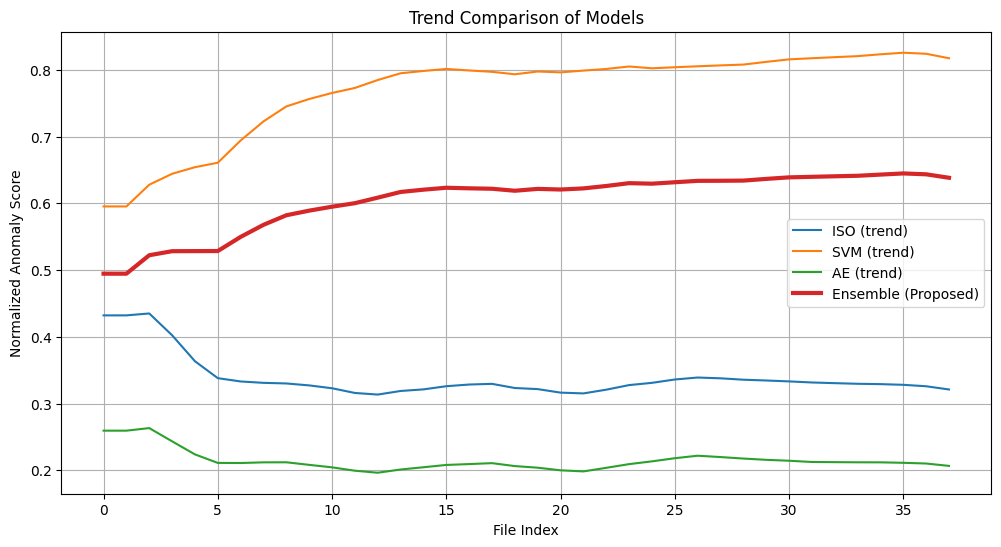

STD ISO: 0.03127277890100392
STD SVM: 0.06662773323205703
STD AE : 0.015760300753248968
STD ENS: 0.04380654220408827


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM


# SETTINGS

Fs = 20480
window_size = Fs
folder_path = "/content/filedata"

files = sorted(os.listdir(folder_path))


# FEATURE FUNCTION

def extract_features(signal, Fs):

    features = []

    # ---- Time domain ----
    mean = np.mean(signal)
    std = np.std(signal)
    rms = np.sqrt(np.mean(signal**2))
    peak = np.max(np.abs(signal))
    ptp = np.ptp(signal)

    features.extend([mean, std, rms, peak, ptp])

    # ---- Frequency domain ----
    fft_vals = np.abs(np.fft.rfft(signal))
    freqs = np.fft.rfftfreq(len(signal), 1/Fs)

    sum_fft_vals = np.sum(fft_vals)

    # Ensure sum_fft_vals is not zero to avoid division by zero
    if sum_fft_vals == 0:
        centroid = 0
        energy = 0
        entropy = 0
    else:
        centroid = np.sum(freqs * fft_vals) / (sum_fft_vals + 1e-6)
        energy = np.sum(fft_vals**2)

        # Handle 0 * log(0) terms in entropy calculation
        psd_norm = fft_vals / (sum_fft_vals + 1e-6)
        # Replace 0 * log(0) with 0
        entropy_term = np.where(psd_norm > 0, psd_norm * np.log(psd_norm), 0)
        entropy = -np.sum(entropy_term)

    features.extend([centroid, energy, entropy])

    return features


# STEP 1: EXTRACT ALL DATA

X_all = []
file_segment_counts = []

for file in files:

    data = np.loadtxt(os.path.join(folder_path, file))
    signals = data[:, :8]

    segments = []
    for start in range(0, len(signals) - window_size + 1, window_size):
        segments.append(signals[start:start + window_size, :])

    file_segment_counts.append(len(segments))

    for segment in segments:
        feature_vector = []

        for ch in range(segment.shape[1]):
            f = extract_features(segment[:, ch], Fs)
            feature_vector.extend(f)

        X_all.append(feature_vector)

X_all = np.array(X_all)


# STEP 2: SCALE

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)


# STEP 3: MODELS

iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(X_scaled)

svm = OneClassSVM(nu=0.05, gamma='scale')
svm.fit(X_scaled)

# ----- AUTOENCODER -----
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_autoencoder(input_dim):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dense(16, activation='relu'),
        Dense(32, activation='relu'),
        Dense(input_dim, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

ae = build_autoencoder(X_scaled.shape[1])
ae.fit(X_scaled, X_scaled, epochs=10, batch_size=32, verbose=0)


# STEP 4: CONTINUOUS SCORES

iso_scores_all = -iso.decision_function(X_scaled)
svm_scores_all = -svm.decision_function(X_scaled)

recon = ae.predict(X_scaled)
mse = np.mean((X_scaled - recon)**2, axis=1)
ae_scores_all = mse


# STEP 5: NORMALIZE SCORES

iso_norm = MinMaxScaler().fit_transform(iso_scores_all.reshape(-1,1)).flatten()
svm_norm = MinMaxScaler().fit_transform(svm_scores_all.reshape(-1,1)).flatten()
ae_norm  = MinMaxScaler().fit_transform(ae_scores_all.reshape(-1,1)).flatten()


# STEP 6: SPLIT BACK + ENSEMBLE

iso_plot = []
svm_plot = []
ae_plot = []
ensemble_plot = []

start = 0

for count in file_segment_counts:

    end = start + count

    iso_seg = iso_norm[start:end]
    svm_seg = svm_norm[start:end]
    ae_seg  = ae_norm[start:end]

    # ---- store individual (mean per file) ----
    iso_plot.append(np.mean(iso_seg))
    svm_plot.append(np.mean(svm_seg))
    ae_plot.append(np.mean(ae_seg))

    # ---- adaptive weights (STD based) ----
    iso_conf = np.mean(iso_seg)
    svm_conf = np.mean(svm_seg)
    ae_conf  = np.mean(ae_seg)

    total = iso_conf + svm_conf + ae_conf + 1e-6

    w_iso = iso_conf / total
    w_svm = svm_conf / total
    w_ae  = ae_conf  / total

    # ---- ensemble ----
    weighted_score = (
        w_iso * iso_seg +
        w_svm * svm_seg +
        w_ae  * ae_seg
    )

    ensemble_plot.append(np.mean(weighted_score))

    start = end

# Normalize all scores after the loop
all_scores = np.vstack([iso_plot, svm_plot, ae_plot, ensemble_plot]).T
all_scaled = MinMaxScaler().fit_transform(all_scores)

iso_plot_n = all_scaled[:,0]
svm_plot_n = all_scaled[:,1]
ae_plot_n  = all_scaled[:,2]
ens_plot_n = all_scaled[:,3]


# STEP 7: SMOOTHING

def smooth(y, window=5):
    return np.convolve(y, np.ones(window)/window, mode='same')


iso_s = smooth(iso_plot_n)
svm_s = smooth(svm_plot_n)
ae_s  = smooth(ae_plot_n)
ens_s = smooth(ens_plot_n)
def trend(y):
    return np.cumsum(y) / (np.arange(len(y)) + 1)

iso_t = trend(iso_s)
svm_t = trend(svm_s)
ae_t  = trend(ae_s)
ens_t = trend(ens_s)


# STEP 8: PLOT

plt.figure(figsize=(12,6))

plt.plot(iso_t, label="ISO (trend)")
plt.plot(svm_t, label="SVM (trend)")
plt.plot(ae_t, label="AE (trend)")
plt.plot(ens_t, linewidth=3, label="Ensemble (Proposed)")

plt.xlabel("File Index")
plt.ylabel("Normalized Anomaly Score")
plt.title("Trend Comparison of Models")

plt.legend()
plt.grid()
plt.show()
print("STD ISO:", np.std(iso_t))
print("STD SVM:", np.std(svm_t))
print("STD AE :", np.std(ae_t))
print("STD ENS:", np.std(ens_t))

In [ ]:
import os
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM


# SETTINGS

Fs = 20480
window_size = Fs // 20
folder_path = "/content/filedata"

files = sorted(os.listdir(folder_path))


# FEATURE FUNCTION (same)

def extract_features(signal, Fs):

    features = []

    mean = np.mean(signal)
    std = np.std(signal)
    rms = np.sqrt(np.mean(signal**2))
    peak = np.max(np.abs(signal))
    ptp = np.ptp(signal)

    features.extend([mean, std, rms, peak, ptp])

    fft_vals = np.abs(np.fft.rfft(signal))
    freqs = np.fft.rfftfreq(len(signal), 1/Fs)

    centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-6)
    energy = np.sum(fft_vals**2)
    entropy = -np.sum((fft_vals/(np.sum(fft_vals)+1e-6)) *
                      np.log(fft_vals/(np.sum(fft_vals)+1e-6) + 1e-6))

    features.extend([centroid, energy, entropy])

    return features


# STEP 1: EXTRACT ALL FEATURES

X_all = []
file_segment_counts = []

for file in files:

    data = np.loadtxt(os.path.join(folder_path, file))
    signals = data[:, :8]

    segments = []
    for start in range(0, len(signals) - window_size + 1, window_size):
        segments.append(signals[start:start + window_size, :])

    file_segment_counts.append(len(segments))

    for segment in segments:
        feature_vector = []

        for ch in range(segment.shape[1]):
            f = extract_features(segment[:, ch], Fs)
            feature_vector.extend(f)

        X_all.append(feature_vector)

X_all = np.array(X_all)


# STEP 2: SCALE

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)


# STEP 3: MODELS

iso = IsolationForest(contamination=0.05, random_state=42)
iso_labels_all = iso.fit_predict(X_scaled)

svm = OneClassSVM(nu=0.05, gamma='scale')
svm_labels_all = svm.fit_predict(X_scaled)

# -------- AUTOENCODER --------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_autoencoder(input_dim):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dense(16, activation='relu'),
        Dense(32, activation='relu'),
        Dense(input_dim, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

ae = build_autoencoder(X_scaled.shape[1])
ae.fit(X_scaled, X_scaled, epochs=10, batch_size=32, verbose=0)

recon = ae.predict(X_scaled)
mse = np.mean((X_scaled - recon)**2, axis=1)

threshold_ae = np.percentile(mse, 90)
ae_labels_all = np.where(mse > threshold_ae, -1, 1)


# STEP 4: CONVERT TO BINARY

iso_bin_all = (iso_labels_all == -1).astype(int)
svm_bin_all = (svm_labels_all == -1).astype(int)
ae_bin_all  = (ae_labels_all == -1).astype(int)


# STEP 5: SPLIT BACK PER FILE

iso_counts = []
svm_counts = []
ae_counts = []
ensemble_counts = []

start = 0

for count in file_segment_counts:

    end = start + count

    iso_seg = iso_bin_all[start:end]
    svm_seg = svm_bin_all[start:end]
    ae_seg  = ae_bin_all[start:end]

    # ---- single model counts ----
    iso_counts.append(np.sum(iso_seg))
    svm_counts.append(np.sum(svm_seg))
    ae_counts.append(np.sum(ae_seg))

    # ---- simple ensemble (majority voting) ----
    combined = iso_seg + svm_seg + ae_seg
    ensemble = (combined >= 2).astype(int)

    ensemble_counts.append(np.sum(ensemble))

    start = end


# PRINT RESULTS

print("\nANOMALY COUNTS PER FILE\n")

for i in range(len(files)):
    print(f"File {i}: ISO={iso_counts[i]}, SVM={svm_counts[i]}, AE={ae_counts[i]}, ENS={ensemble_counts[i]}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

ANOMALY COUNTS PER FILE

File 0: ISO=1, SVM=0, AE=2, ENS=1
File 1: ISO=3, SVM=4, AE=4, ENS=4
File 2: ISO=1, SVM=0, AE=1, ENS=1
File 3: ISO=1, SVM=0, AE=0, ENS=0
File 4: ISO=0, SVM=1, AE=2, ENS=1
File 5: ISO=0, SVM=0, AE=1, ENS=0
File 6: ISO=1, SVM=3, AE=4, ENS=2
File 7: ISO=1, SVM=2, AE=2, ENS=1
File 8: ISO=0, SVM=2, AE=4, ENS=1
File 9: ISO=0, SVM=0, AE=0, ENS=0
File 10: ISO=0, SVM=0, AE=0, ENS=0
File 11: ISO=1, SVM=1, AE=4, ENS=1
File 12: ISO=1, SVM=0, AE=1, ENS=0
File 13: ISO=1, SVM=0, AE=0, ENS=0
File 14: ISO=0, SVM=1, AE=0, ENS=0
File 15: ISO=2, SVM=2, AE=5, ENS=3
File 16: ISO=0, SVM=0, AE=0, ENS=0
File 17: ISO=0, SVM=1, AE=3, ENS=1
File 18: ISO=0, SVM=1, AE=2, ENS=1
File 19: ISO=2, SVM=4, AE=4, ENS=3
File 20: ISO=1, SVM=0, AE=1, ENS=0
File 21: ISO=1, SVM=0, AE=3, ENS=0
File 22: ISO=2, SVM=1, AE=1, ENS=1
File 23: ISO=3, SVM=1, AE=2, ENS=2
File 24: ISO=2, SVM=10, AE=1, ENS=2
File 25: ISO=2, SVM=0, AE=4, ENS=1
File 26: ISO=0, SVM=0, AE=2, ENS=0

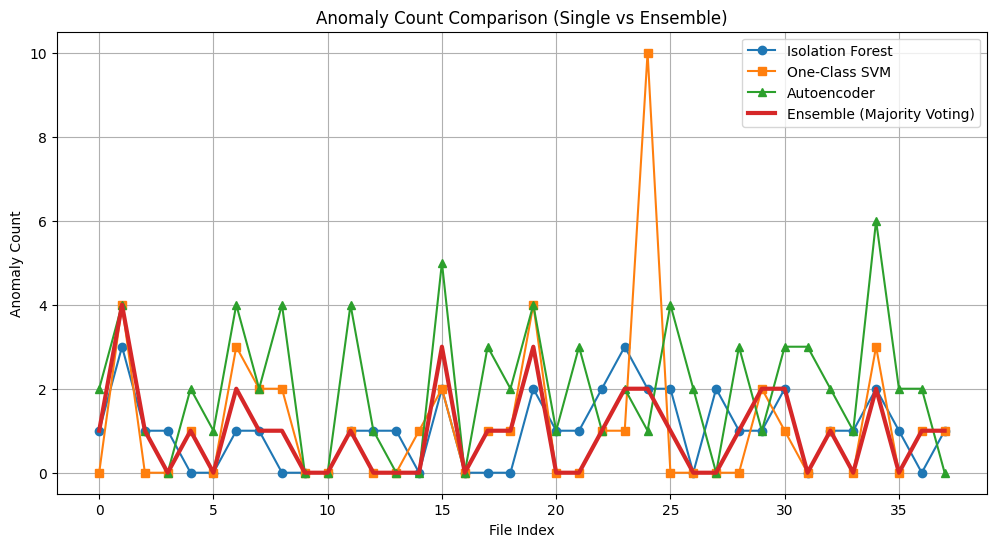

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(iso_counts))

plt.figure(figsize=(12,6))

plt.plot(x, iso_counts, marker='o', label="Isolation Forest")
plt.plot(x, svm_counts, marker='s', label="One-Class SVM")
plt.plot(x, ae_counts, marker='^', label="Autoencoder")
plt.plot(x, ensemble_counts, linewidth=3, label="Ensemble (Majority Voting)")

plt.xlabel("File Index")
plt.ylabel("Anomaly Count")
plt.title("Anomaly Count Comparison (Single vs Ensemble)")

plt.legend()
plt.grid()
plt.show()

### equal weight vs Adaptive weight

In [ ]:
equal_plot = []
adaptive_plot = []

start = 0

for count in file_segment_counts:
    from sklearn.preprocessing import MinMaxScaler

    # The scaler should be instantiated within the loop to reset for each segment if needed,
    # but the fit_transform on equal_plot/adaptive_plot should happen AFTER the loop.
    # We don't need a scaler here for equal_plot and adaptive_plot yet.

    end = start + count

    iso_seg = iso_scores_all[start:end]
    svm_seg = svm_scores_all[start:end]
    ae_seg  = ae_scores_all[start:end]


    # 1. EQUAL WEIGHTS

    equal_score = (iso_seg + svm_seg + ae_seg) / 3
    equal_plot.append(np.mean(equal_score))


    # 2. ADAPTIVE WEIGHTS

    iso_conf = np.mean(iso_seg)
    svm_conf = np.mean(svm_seg)
    ae_conf  = np.mean(ae_seg)

    total = iso_conf + svm_conf + ae_conf + 1e-6

    w_iso = iso_conf / total
    w_svm = svm_conf / total
    w_ae  = ae_conf  / total



    if total == 0:
        w_iso = w_svm = w_ae = 1/3
    else:
        w_iso = iso_conf / total
        w_svm = svm_conf / total
        w_ae  = ae_conf  / total


    adaptive_score = (
        w_iso * iso_seg +
        w_svm * svm_seg +
        w_ae  * ae_seg
    )

    adaptive_plot.append(np.mean(adaptive_score))

    start = end

# Normalize the plots after the loop has completed
scaler = MinMaxScaler()
equal_plot = np.nan_to_num(equal_plot)
adaptive_plot = np.nan_to_num(adaptive_plot)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
def smooth(y, window=5):
    return np.convolve(y, np.ones(window)/window, mode='same')

def trend(y):
    return np.cumsum(y) / (np.arange(len(y)) + 1)

from sklearn.preprocessing import MinMaxScaler

all_scores = np.vstack([equal_plot, adaptive_plot]).T
all_scaled = MinMaxScaler().fit_transform(all_scores)

equal_plot_n = all_scaled[:,0]
adaptive_plot_n = all_scaled[:,1]

equal_t = trend(smooth(equal_plot_n))
adaptive_t = trend(smooth(adaptive_plot_n))

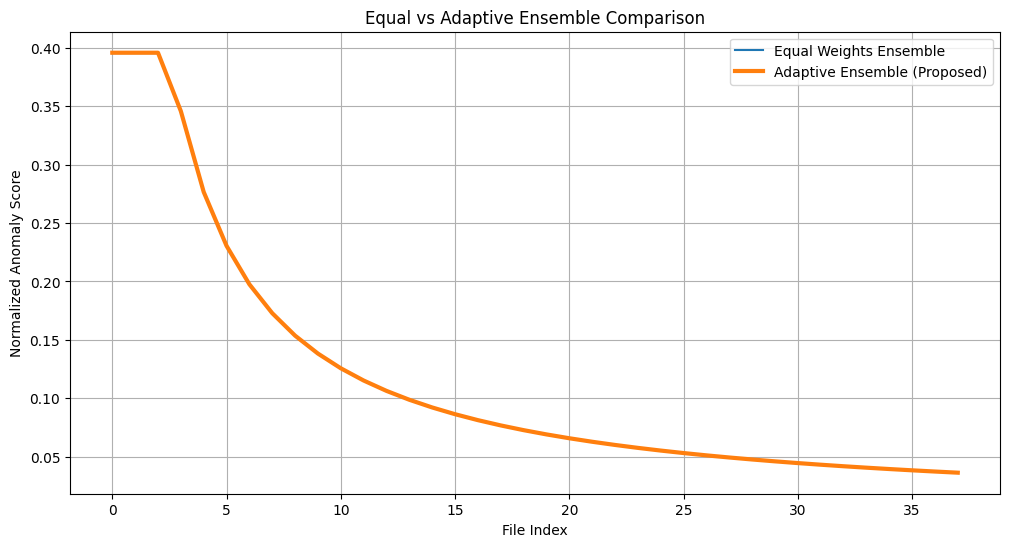

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(equal_t, label="Equal Weights Ensemble")
plt.plot(adaptive_t, linewidth=3, label="Adaptive Ensemble (Proposed)")

plt.xlabel("File Index")
plt.ylabel("Normalized Anomaly Score")
plt.title("Equal vs Adaptive Ensemble Comparison")

plt.legend()
plt.grid()
plt.show()

In [ ]:
print("STD Equal:", np.std(equal_t))
print("STD Adaptive:", np.std(adaptive_t))

STD Equal: 0.10631964886220742
STD Adaptive: 0.10641034175899475


### 1 Vs 8 Channel

In [ ]:
X_single = []

for file in files:
    data = np.loadtxt(os.path.join(folder_path, file))
    signals = data[:, :8]

    segments = []
    for start in range(0, len(signals) - window_size + 1, window_size):
        segments.append(signals[start:start + window_size, :])

    for segment in segments:
        # ONLY channel 0
        f = extract_features(segment[:, 0], Fs)
        X_single.append(f)

X_single = np.array(X_single)

In [ ]:
X_multi = []

for file in files:
    data = np.loadtxt(os.path.join(folder_path, file))
    signals = data[:, :8]

    segments = []
    for start in range(0, len(signals) - window_size + 1, window_size):
        segments.append(signals[start:start + window_size, :])

    for segment in segments:
        feature_vector = []

        for ch in range(segment.shape[1]):
            f = extract_features(segment[:, ch], Fs)
            feature_vector.extend(f)

        X_multi.append(feature_vector)

X_multi = np.array(X_multi)

In [ ]:
from sklearn.preprocessing import StandardScaler

X_single = StandardScaler().fit_transform(X_single)
X_multi  = StandardScaler().fit_transform(X_multi)

In [ ]:
iso_single = IsolationForest(contamination=0.05, random_state=42)
iso_multi  = IsolationForest(contamination=0.05, random_state=42)

iso_single.fit(X_single)
iso_multi.fit(X_multi)

single_scores = -iso_single.decision_function(X_single)
multi_scores  = -iso_multi.decision_function(X_multi)

In [ ]:
single_plot = []
multi_plot = []

start = 0

for count in file_segment_counts:

    end = start + count

    single_plot.append(np.mean(single_scores[start:end]))
    multi_plot.append(np.mean(multi_scores[start:end]))

    start = end

In [ ]:
from sklearn.preprocessing import MinMaxScaler

all_scores = np.vstack([single_plot, multi_plot]).T
all_scaled = MinMaxScaler().fit_transform(all_scores)

single_plot = all_scaled[:,0]
multi_plot  = all_scaled[:,1]

In [ ]:
def smooth(y, window=5):
    return np.convolve(y, np.ones(window)/window, mode='same')

def trend(y):
    return np.cumsum(y) / (np.arange(len(y)) + 1)

single_t = trend(smooth(single_plot))
multi_t  = trend(smooth(multi_plot))

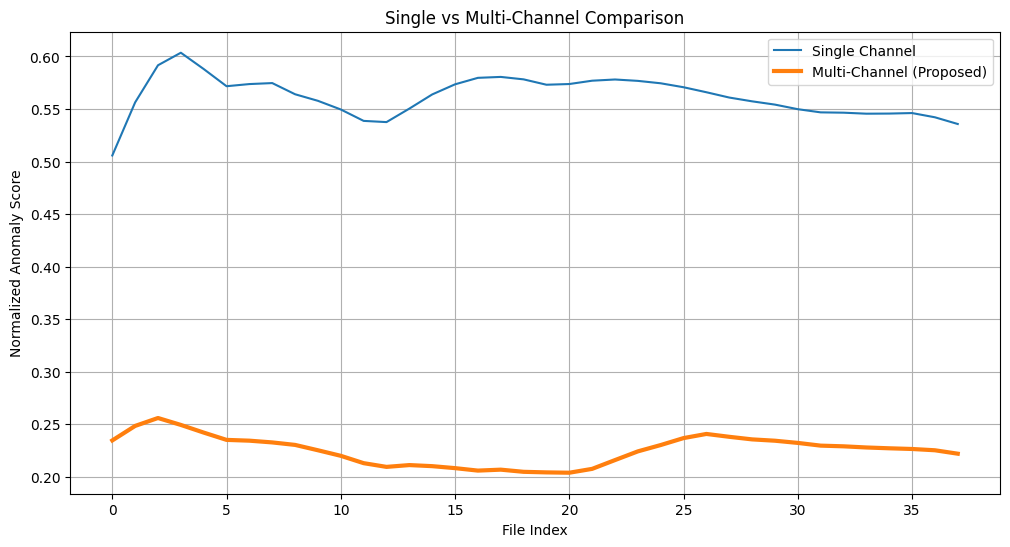

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(single_t, label="Single Channel")
plt.plot(multi_t, linewidth=3, label="Multi-Channel (Proposed)")

plt.xlabel("File Index")
plt.ylabel("Normalized Anomaly Score")
plt.title("Single vs Multi-Channel Comparison")

plt.legend()
plt.grid()
plt.show()

In [ ]:
print("STD Single:", np.std(single_t))
print("STD Multi :", np.std(multi_t))

STD Single: 0.018615644245051598
STD Multi : 0.013702586034577812


### Score Vs Count

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

all_data = np.vstack([ensemble_plot, ensemble_counts]).T
scaled = MinMaxScaler().fit_transform(all_data)

score_n = scaled[:,0]
count_n = scaled[:,1]

In [ ]:
def smooth(y, window=5):
    return np.convolve(y, np.ones(window)/window, mode='same')

def trend(y):
    return np.cumsum(y) / (np.arange(len(y)) + 1)

score_t = trend(smooth(score_n))
count_t = count_n

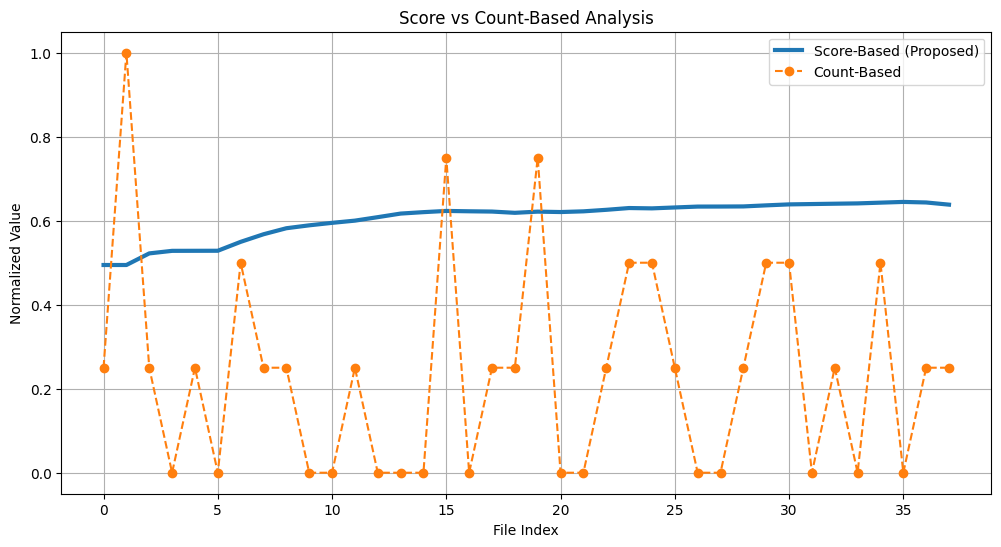

In [ ]:
plt.figure(figsize=(12,6))

# Score (smooth trend)
plt.plot(score_t, linewidth=3, label="Score-Based (Proposed)")

# Count (raw)
plt.plot(count_t, linestyle='--', marker='o', label="Count-Based")

plt.xlabel("File Index")
plt.ylabel("Normalized Value")
plt.title("Score vs Count-Based Analysis")

plt.legend()
plt.grid()
plt.show()


===== MODEL PERFORMANCE =====

Isolation Forest:
Precision: 0.375
Recall   : 0.15789473684210525
F1 Score : 0.2222222222222222
ROC-AUC  : 0.47645429362880887

One-Class SVM:
Precision: 0.48
Recall   : 0.631578947368421
F1 Score : 0.5454545454545454
ROC-AUC  : 0.556786703601108

Autoencoder:
Precision: 0.4
Recall   : 0.10526315789473684
F1 Score : 0.16666666666666666
ROC-AUC  : 0.45983379501385047

Ensemble (Proposed):
Precision: 0.42857142857142855
Recall   : 0.15789473684210525
F1 Score : 0.23076923076923078
ROC-AUC  : 0.5650969529085873


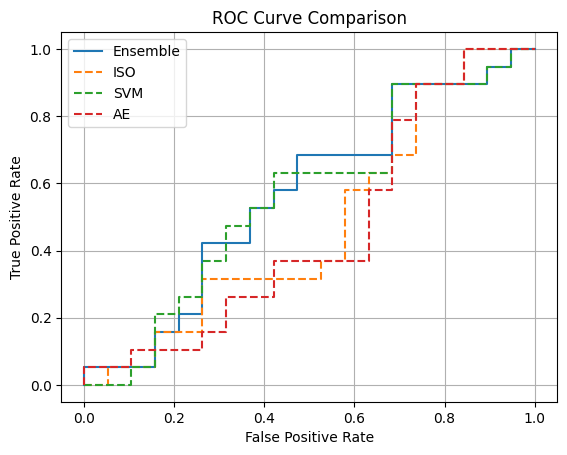


===== SUMMARY TABLE =====

Model		Precision	Recall		F1		ROC-AUC
-------------------------------------------------------------
ISO		0.375		0.158		0.222		0.476
SVM		0.480		0.632		0.545		0.557
AE 		0.400		0.105		0.167		0.460
ENS		0.429		0.158		0.231		0.565


In [ ]:

# FULL EVALUATION CODE (PSEUDO-LABEL BASED)


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve


# STEP 1: TOTAL DATA LENGTH

num_files = len(ens_plot_n)


# STEP 2: CREATE PSEUDO LABELS
# 0 = normal, 1 = anomaly

labels = np.zeros(num_files)
labels[int(0.5 * num_files):] = 1   # 50% split


# STEP 3: EVALUATION FUNCTION

def evaluate_model(scores, labels, percentile=75):

    # threshold based on percentile
    threshold = np.mean(scores) + 0.5 * np.std(scores)

    # binary predictions
    preds = (scores > threshold).astype(int)

    # metrics
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    roc = roc_auc_score(labels, scores)

    return precision, recall, f1, roc


# STEP 4: EVALUATE ALL MODELS

iso_metrics = evaluate_model(iso_plot_n, labels)
svm_metrics = evaluate_model(svm_plot_n, labels)
ae_metrics  = evaluate_model(ae_plot_n, labels)
ens_metrics = evaluate_model(ens_plot_n, labels)


# STEP 5: PRINT RESULTS

print("\n===== MODEL PERFORMANCE =====\n")

print("Isolation Forest:")
print("Precision:", iso_metrics[0])
print("Recall   :", iso_metrics[1])
print("F1 Score :", iso_metrics[2])
print("ROC-AUC  :", iso_metrics[3])
print()

print("One-Class SVM:")
print("Precision:", svm_metrics[0])
print("Recall   :", svm_metrics[1])
print("F1 Score :", svm_metrics[2])
print("ROC-AUC  :", svm_metrics[3])
print()

print("Autoencoder:")
print("Precision:", ae_metrics[0])
print("Recall   :", ae_metrics[1])
print("F1 Score :", ae_metrics[2])
print("ROC-AUC  :", ae_metrics[3])
print()

print("Ensemble (Proposed):")
print("Precision:", ens_metrics[0])
print("Recall   :", ens_metrics[1])
print("F1 Score :", ens_metrics[2])
print("ROC-AUC  :", ens_metrics[3])



# STEP 6: ROC CURVE PLOT

plt.figure()

# Ensemble ROC
fpr, tpr, _ = roc_curve(labels, ens_plot_n)
plt.plot(fpr, tpr, label="Ensemble")

# ISO
fpr, tpr, _ = roc_curve(labels, iso_plot_n)
plt.plot(fpr, tpr, linestyle='--', label="ISO")

# SVM
fpr, tpr, _ = roc_curve(labels, svm_plot_n)
plt.plot(fpr, tpr, linestyle='--', label="SVM")

# AE
fpr, tpr, _ = roc_curve(labels, ae_plot_n)
plt.plot(fpr, tpr, linestyle='--', label="AE")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()



# STEP 7: TABLE FORMAT (OPTIONAL)

print("\n===== SUMMARY TABLE =====\n")

print("Model\t\tPrecision\tRecall\t\tF1\t\tROC-AUC")
print("-------------------------------------------------------------")
print(f"ISO\t\t{iso_metrics[0]:.3f}\t\t{iso_metrics[1]:.3f}\t\t{iso_metrics[2]:.3f}\t\t{iso_metrics[3]:.3f}")
print(f"SVM\t\t{svm_metrics[0]:.3f}\t\t{svm_metrics[1]:.3f}\t\t{svm_metrics[2]:.3f}\t\t{svm_metrics[3]:.3f}")
print(f"AE \t\t{ae_metrics[0]:.3f}\t\t{ae_metrics[1]:.3f}\t\t{ae_metrics[2]:.3f}\t\t{ae_metrics[3]:.3f}")
print(f"ENS\t\t{ens_metrics[0]:.3f}\t\t{ens_metrics[1]:.3f}\t\t{ens_metrics[2]:.3f}\t\t{ens_metrics[3]:.3f}")